# 23CSE301 Machine Learning -- Capstone Project
## Regression Track -- Review 1
### Algorithm 9: Support Vector Regressor (SVR)

**Dataset:** Enhanced Box Office Data (2000-2024)
**Target variable:** `$Worldwide` gross revenue (log-transformed for modeling)
**Random seed:** 42

Requires scaled features (handled by the pipeline's `StandardScaler`, fit per-fold). `C` and `kernel` are tuned via GridSearchCV. SVR has no native importance attribute, so Section 8 uses permutation importance instead.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
DATA_PATH = "../data/enhanced_box_office_data_2000-2024.csv"

sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.dpi'] = 100

from sklearn.svm import SVR


## 1. Load and Audit the Dataset

In [4]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

print()
print("--- Data types ---")
print(df.dtypes)
print()
print("--- Missing value counts ---")
print(df.isnull().sum())
print()
print("--- Duplicate rows ---")
print("Duplicate rows:", df.duplicated().sum())
print()
print("--- Target ($Worldwide) distribution summary ---")
print(df['$Worldwide'].describe())


Shape: (5000, 13)


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America



--- Data types ---
Rank                      int64
Release Group               str
$Worldwide              float64
$Domestic               float64
Domestic %              float64
$Foreign                float64
Foreign %               float64
Year                      int64
Genres                      str
Rating                      str
Vote_Count              float64
Original_Language           str
Production_Countries        str
dtype: object

--- Missing value counts ---
Rank                      0
Release Group             0
$Worldwide                0
$Domestic                 0
Domestic %                0
$Foreign                  0
Foreign %                 0
Year                      0
Genres                  178
Rating                  170
Vote_Count              170
Original_Language       170
Production_Countries    200
dtype: int64

--- Duplicate rows ---
Duplicate rows: 0

--- Target ($Worldwide) distribution summary ---
count    5.000000e+03
mean     1.192137e+08
std    

## 2. Data Cleaning, Leakage Removal & Feature Engineering
- **Missing values:** `Rating` parsed from text to numeric; remaining numeric
  gaps are median-imputed and categorical gaps constant-imputed, both **inside**
  the pipeline (fit on the training fold only).
- **Duplicates:** checked (0 found).
- **Outliers:** audited via IQR; kept (genuine blockbusters) and handled via
  log-transforming the target instead of deletion.
- **Leakage columns dropped:** `$Domestic`, `$Foreign`, `Domestic %`,
  `Foreign %`, `Rank` -- all mathematically derived from `$Worldwide`.
- **Engineered features:** `Genre_Count`, `Primary_Genre`, `Country_Count`,
  `Decade` (see EDA notebook / project README for full justification).


Rows before duplicate removal: 5000
Rows after duplicate removal:  5000


,feature,IQR_lower,IQR_upper,outlier_count
0,$Worldwide,-1.179827e+08,2.624036e+08,553
2,Vote_Count,-4.084375e+03,7.354625e+03,426
3,Rating_numeric,4.365875e+00,8.752875e+00,101
1,Year,1.988000e+03,2.036000e+03,0


Outliers are retained unless a justified domain rule exists; tree models are generally robust to monotonic feature scaling, while SVR/KNN require scaling.


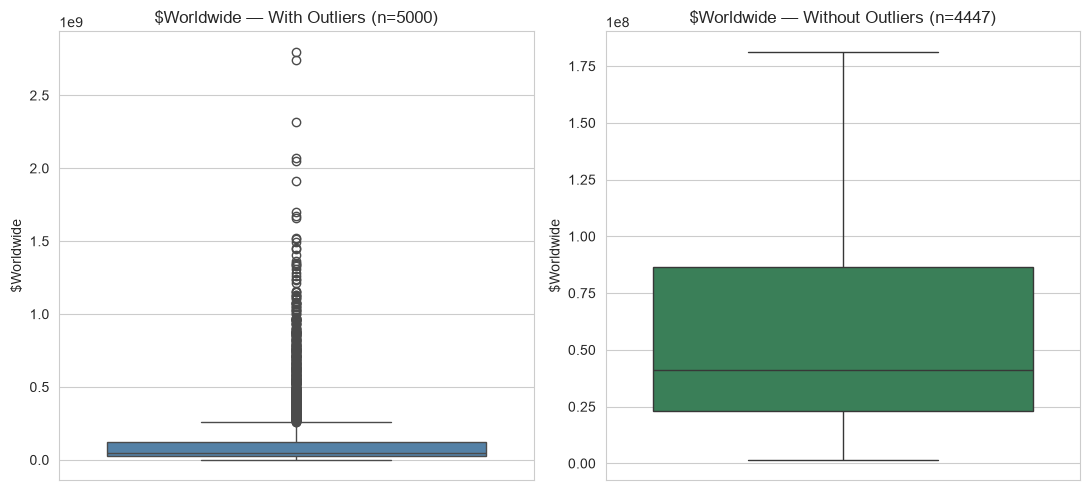

After imputing:
 Rating_numeric    0
Vote_Count        0
dtype: int64


,Primary_Genre,Language_Grouped,Decade,Year,Rating_numeric,Vote_Count,Genre_Count,Country_Count
0,Adventure,en,2000s,2000,6.126,6741.0,3,1
1,Action,en,2000s,2000,8.217,19032.0,3,2
2,Adventure,en,2000s,2000,7.663,11403.0,2,1
3,Comedy,en,2000s,2000,6.450,3944.0,2,2
4,Animation,en,2000s,2000,6.544,2530.0,3,1


In [5]:
# --- Parse Rating from "x.xxx/10" text format to numeric ---
df['Rating_numeric'] = df['Rating'].str.split('/').str[0].astype(float)

# --- Drop leakage-inducing columns before any further analysis ---
leak_cols = ['$Domestic', 'Domestic %', '$Foreign', 'Foreign %', 'Rank']
drop_cols = leak_cols + ['Release Group', 'Rating']
df_clean = df.drop(columns=drop_cols)

# --- Remove exact duplicate rows ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
after = len(df_clean)
print(f"Rows before duplicate removal: {before}")
print(f"Rows after duplicate removal:  {after}")

# --- IQR outlier audit across every numeric column (reported, not blindly deleted) ---
numeric_cols_for_audit = df_clean.select_dtypes(include=[np.number]).columns.tolist()
outlier_report = []

for col in numeric_cols_for_audit:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report.append([col, lower, upper, int(count)])

outlier_report = pd.DataFrame(outlier_report, columns=["feature", "IQR_lower", "IQR_upper", "outlier_count"])
display(outlier_report.sort_values("outlier_count", ascending=False))

print("Outliers are retained unless a justified domain rule exists; tree models are "
      "generally robust to monotonic feature scaling, while SVR/KNN require scaling.")

# Observation:
# - $Worldwide has the largest outlier count -- driven by genuine blockbuster releases,
#   not data-entry errors, so it is retained and handled via log-transforming the target
#   rather than deletion.
# - Vote_Count shows a similar pattern (popular titles collect disproportionately more
#   votes), consistent with its right-skewed distribution seen in the EDA notebook.
# - Rating_numeric and Year show few or no IQR-flagged outliers, as expected for a
#   bounded score and a roughly uniform release-year range.

# --- Box plot: $Worldwide with vs without outliers (visual confirmation) ---
q1, q3 = df_clean['$Worldwide'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr

df_no_outliers = df_clean.loc[
    (df_clean['$Worldwide'] >= lower_fence) & (df_clean['$Worldwide'] <= upper_fence),
    '$Worldwide'
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(y=df_clean['$Worldwide'], ax=axes[0], color='steelblue')
axes[0].set_title(f'$Worldwide — With Outliers (n={len(df_clean)})')
axes[0].set_ylabel('$Worldwide')

sns.boxplot(y=df_no_outliers, ax=axes[1], color='seagreen', showfliers=False)
axes[1].set_title(f'$Worldwide — Without Outliers (n={len(df_no_outliers)})')
axes[1].set_ylabel('$Worldwide')

plt.tight_layout()
plt.savefig('worldwide_outlier_boxplots.png', bbox_inches='tight')
plt.show()

# --- Feature engineering ---
df_clean['Genres'] = df_clean['Genres'].fillna('Unknown')
df_clean['Genre_Count'] = df_clean['Genres'].apply(lambda x: len(str(x).split(',')))
df_clean['Primary_Genre'] = df_clean['Genres'].apply(lambda x: str(x).split(',')[0].strip())

df_clean['Production_Countries'] = df_clean['Production_Countries'].fillna('Unknown')
df_clean['Country_Count'] = df_clean['Production_Countries'].apply(lambda x: len(str(x).split(',')))

df_clean['Original_Language'] = df_clean['Original_Language'].fillna('Unknown')
# collapse rare languages into 'Other' to control cardinality
top_langs = df_clean['Original_Language'].value_counts().nlargest(8).index
df_clean['Language_Grouped'] = df_clean['Original_Language'].where(
    df_clean['Original_Language'].isin(top_langs), 'Other'
)

df_clean['Decade'] = (df_clean['Year'] // 10 * 10).astype(str) + 's'

# Median-impute remaining numeric missingness
se = SimpleImputer(strategy='median')
df_clean['Rating_numeric'] = se.fit_transform(df_clean[['Rating_numeric']])
df_clean['Vote_Count'] = se.fit_transform(df_clean[['Vote_Count']])

# Final feature set
categorical_features = ['Primary_Genre', 'Language_Grouped', 'Decade']
numeric_features = ['Year', 'Rating_numeric', 'Vote_Count', 'Genre_Count', 'Country_Count']

X = df_clean[categorical_features + numeric_features]
y = np.log1p(df_clean['$Worldwide'])   # log-transformed target
y_raw = df_clean['$Worldwide']          # kept for dollar-scale evaluation

print("After imputing:\n", df_clean[['Rating_numeric', 'Vote_Count']].isnull().sum())
X.head()

## 3. Train/Test Split & Leakage-Safe Preprocessing Pipeline
80:20 split with a fixed random seed, identical across all 10 notebooks so
every algorithm is compared on the same held-out test set. Imputation,
encoding, and scaling are wrapped inside the model `Pipeline` so
`GridSearchCV`/`cross_val_score` refit them per CV fold -- the strictest
guarantee against leakage.

In [4]:
# --- Train/test split: 80:20, fixed random_state -> IDENTICAL split across
# every notebook in this project, so all 10 models are compared fairly on the
# same held-out test set as required by the guidelines. ---
X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X, y, y_raw, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

decade_order = sorted(X['Decade'].unique(), key=lambda d: int(d[:-1]))

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', min_frequency=0.02, sparse_output=False))
])
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[decade_order]))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('ord', ordinal_pipeline, ordinal_features)
])
# NOTE: the preprocessor is wrapped inside the model Pipeline below rather than
# fit once here -- this way GridSearchCV / cross_val_score refit imputation,
# encoding, and scaling on each individual CV fold's training portion, which is
# the strictest way to avoid any leakage between folds.


Train shape: (4000, 8) | Test shape: (1000, 8)


In [5]:
def evaluate(name, y_true_log, y_pred_log):
    """Inverse-transform log-scale predictions to dollars and compute metrics."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(np.clip(y_pred_log, -50, 50))
    return {
        'Model': name,
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }


## 4. Baseline Support Vector Regressor

In [6]:
model = SVR()

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])
baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)
baseline_metrics = evaluate('Support Vector Regressor (baseline)', y_test, baseline_pred)
display(pd.DataFrame([baseline_metrics]))


,Model,R2,RMSE,MAE
0,Support Vector Regressor (baseline),0.582966,1.394882e+08,5.678082e+07


## 5. Hyperparameter Tuning (GridSearchCV, 5-fold)
The rubric requires tuning applied to at least 2 models across the track;
every notebook in this project applies it individually so each algorithm's
best configuration is documented on its own.

In [7]:
param_grid = {'model__C': [1, 10, 50], 'model__kernel': ['rbf', 'linear']}

grid = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2 (log scale):", round(grid.best_score_, 4))

tuned_pipeline = grid.best_estimator_
tuned_pred = tuned_pipeline.predict(X_test)
tuned_metrics = evaluate('Support Vector Regressor (tuned)', y_test, tuned_pred)

comparison_df = pd.DataFrame([baseline_metrics, tuned_metrics])
comparison_df['R2 Improvement'] = comparison_df['R2'] - baseline_metrics['R2']
display(comparison_df)


Best parameters: {'model__C': 1, 'model__kernel': 'rbf'}
Best mean CV R2 (log scale): 0.6507


,Model,R2,RMSE,MAE,R2 Improvement
0,Support Vector Regressor (baseline),0.582966,1.394882e+08,5.678082e+07,0.0
1,Support Vector Regressor (tuned),0.582966,1.394882e+08,5.678082e+07,0.0


## 6. 5-Fold Cross-Validated R² (Tuned Model)

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(tuned_pipeline, X_train, y_train, scoring='r2', cv=cv, n_jobs=-1)
print("5-fold CV R2 scores:", np.round(cv_scores, 4))
print("Mean CV R2:", round(cv_scores.mean(), 4))
print("Std CV R2:", round(cv_scores.std(), 4))


5-fold CV R2 scores: [0.6425 0.6518 0.6523 0.668  0.6348]
Mean CV R2: 0.6499
Std CV R2: 0.0111


## 7. Required Visualisations -- Residuals & Predicted vs Actual

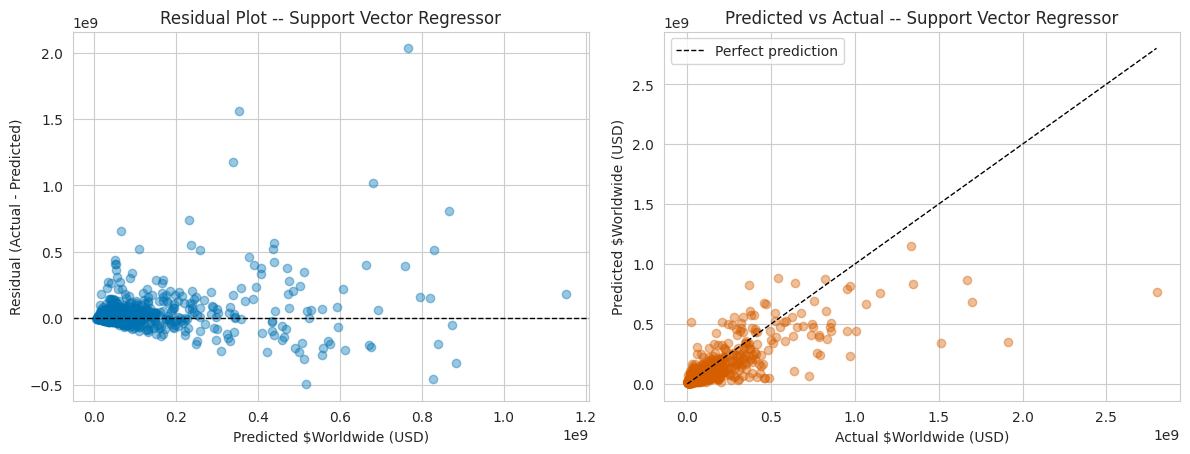

In [9]:
# --- Required visualisations: residual plot + predicted-vs-actual ---
y_pred_log = tuned_pipeline.predict(X_test)
y_pred_dollars = np.expm1(np.clip(y_pred_log, -50, 50))
y_test_dollars = np.expm1(y_test)
residuals = y_test_dollars - y_pred_dollars

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(y_pred_dollars, residuals, alpha=0.4, color='#0072B2')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted $Worldwide (USD)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residual Plot -- Support Vector Regressor')

axes[1].scatter(y_test_dollars, y_pred_dollars, alpha=0.4, color='#D55E00')
lims = [0, max(y_test_dollars.max(), y_pred_dollars.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel('Actual $Worldwide (USD)')
axes[1].set_ylabel('Predicted $Worldwide (USD)')
axes[1].set_title('Predicted vs Actual -- Support Vector Regressor')
axes[1].legend()

plt.tight_layout()
plt.savefig('support_vector_regressor_residuals.png', bbox_inches='tight')
plt.show()


## 8. Feature Importance

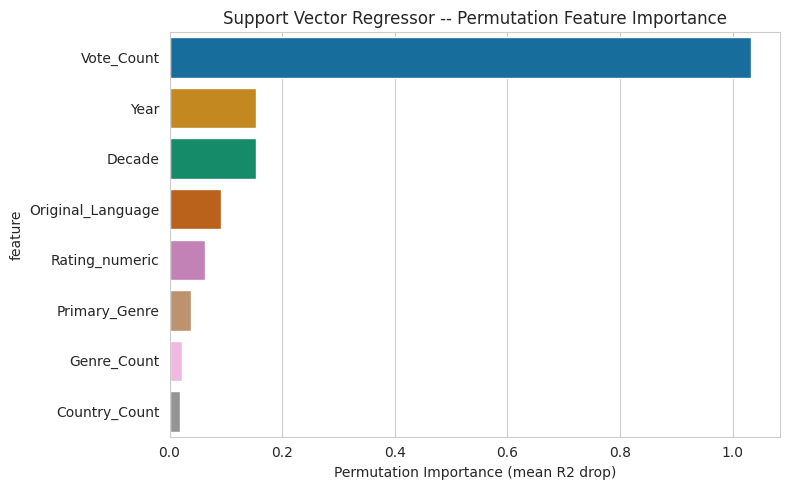

In [10]:
# Support Vector Regressor has no native feature-importance attribute, so we use
# permutation importance instead: shuffle each feature and measure the drop
# in R2 on the held-out test set.
perm_result = permutation_importance(
    tuned_pipeline, X_test, y_test, scoring='r2',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
feature_names_raw = X_test.columns.tolist()
perm_df = pd.DataFrame({
    'feature': feature_names_raw,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance_mean', y='feature', data=perm_df, palette='colorblind')
plt.xlabel('Permutation Importance (mean R2 drop)')
plt.title('Support Vector Regressor -- Permutation Feature Importance')
plt.tight_layout()
plt.savefig('support_vector_regressor_permutation_importance.png', bbox_inches='tight')
plt.show()


## Summary
- Trained baseline and tuned **Support Vector Regressor** on the identical 80:20 split
  used across all 10 notebooks.
- Reported R2, RMSE, and MAE (dollar scale) for baseline and tuned models.
- Applied `GridSearchCV` (5-fold) and reported best parameters + improvement.
- Reported 5-fold cross-validated R2 for the tuned model.
- Produced residual and predicted-vs-actual plots, plus a feature
  importance / coefficient view where applicable.
